In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ndcg_score
from scipy.stats import spearmanr, kendalltau

In [23]:
def load_ranked_csvs(
    shap_csv,
    rollout_csv,
    rank_col="ranking",
    feature_col="feature name",
    score_col="score",
):
    shap = pd.read_csv(shap_csv)
    rollout = pd.read_csv(rollout_csv)

    shap = shap.rename(columns={
        rank_col: "rank",
        feature_col: "feature",
        score_col: "mean_abs_shap",
    })

    rollout = rollout.rename(columns={
        rank_col: "rank",
        feature_col: "feature",
        score_col: "score",
    })
           
    df = pd.merge(
        shap[["feature", "rank", "mean_abs_shap"]],
        rollout[["feature", "rank", "score"]],
        on="feature",
        how="inner",
    )

        

    df["rank_x"] = df["rank_x"].astype(int)
    df["rank_y"] = df["rank_y"].astype(int)

    df = df.sort_values("rank_x").reset_index(drop=True)

    return df

In [24]:
shap_csv = "Results/shap_values/tables/mean_abs_shap_global_age.csv"
rollout_csv = "Results/attention_scores.csv"
df = load_ranked_csvs(shap_csv, rollout_csv)

In [31]:
def compute_metrics(df):
    y_true = df["mean_abs_shap"].to_numpy().reshape(1, -1)
    y_score = df["score"].to_numpy().reshape(1, -1)

    metrics = {
        "NDCG_all": ndcg_score(y_true, y_score),
        "NDCG@6": ndcg_score(y_true, y_score, k=6),
        "NDCG@10": ndcg_score(y_true, y_score, k=10),
        "Spearman_rho": spearmanr(df["rank_x"], df["rank_y"]).correlation,
        "Spearman_p": spearmanr(df["rank_x"], df["rank_y"]).pvalue,
        "Kendall_tau": kendalltau(df["rank_x"], df["rank_y"]).correlation,
        "Kendall_p": kendalltau(df["rank_x"], df["rank_y"]).pvalue,
    }

    return pd.DataFrame([metrics])

In [39]:
metrics = compute_metrics(df)
print(metrics)

   NDCG_all    NDCG@6   NDCG@10  Spearman_rho    Spearman_p  Kendall_tau  \
0  0.961318  0.932051  0.857882       0.78735  2.364248e-16     0.593897   

      Kendall_p  
0  1.590366e-13  


In [37]:
def plot_topk_overlap(df, max_k=20):
    ks = range(1, max_k + 1)
    overlaps = []

    shap_sorted = df.sort_values("rank_x")
    roll_sorted = df.sort_values("rank_y")

    for k in ks:
        shap_topk = set(shap_sorted.head(k)["feature"])
        roll_topk = set(roll_sorted.head(k)["feature"])

        overlap = len(shap_topk & roll_topk) / k
        overlaps.append(overlap)

    plt.figure(figsize=(6, 4))
    plt.plot(ks, overlaps, marker="o")
    plt.xlabel("k")
    plt.ylabel("Top-k overlap ratio")
    plt.title("Agreement between SHAP and rollout rankings")
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

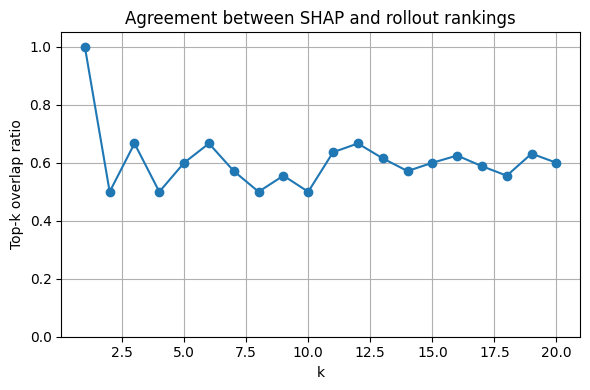

In [38]:
plot_topk_overlap(df)